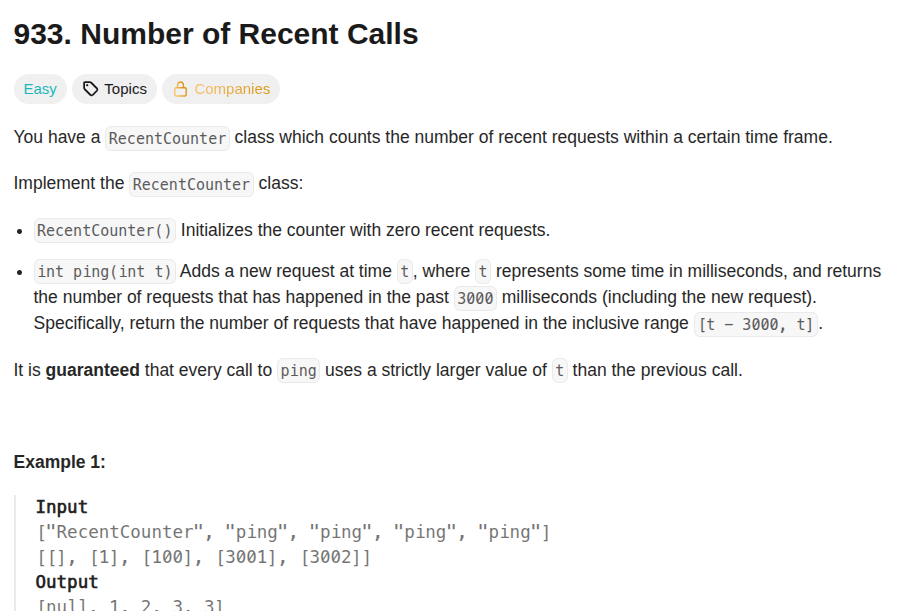

In [1]:
class RecentCounter(object):

    def __init__(self):
        from queue import Queue
        self.counter = Queue()

    def ping(self, t):
        """
        :type t: int
        :rtype: int
        """
        #  inclusive range [t - 3000, t]
        range_start = t - 3000
        range_end =  t
        response = []

        self.counter.put(t)
        for item in self.counter.queue:
            if item >= range_start and item <= range_end:
                response.append(item)
            else:
                self.counter.get(item)
        
        return len(response)

In [ ]:
"""
1. Формулировка задачи
- Написать RecentCounter, который:
    - Принимает в методе ping в качестве t время (int) нового запроса.
    - В методе возвращаются все элементы в виде списка, которые подходят под
    условие [t - 3000, t]
    - При этом элементы, которые оказываются за пределом данного интервала мы удаляем,
    чтобы избежать бесконечного роста очереди и сокращении перебора при новом ping.
- На вход будут поступать целые числа от 1 до 10^9
(!) Сами данные достаточно простые, тут хитрость в реализации

2. Придумывание решения
Думаю тут есть 2 варианта:
- Через срез обычного списка
    - Новый элемент будет добавляться в список через append, сложность О(1)
    - Далее с конца (или начала) будет последовательный перебор элементов
    на соотв-ие условию [t - 3000, t], сложность суммарная - O(n)
    - Найдя элемент, который НЕ удовлетворяет условию, берём индекс следующего элемента start
    - Заменяем список на срез [start:]
    - Возвращаем кол-во элементов в списке О(1)
    (!) Перебор элементов для поиска индекса будет до О(n)
    (!) Сохдание среза займёт, О(k), где k - кол-во элементов в срезе, растёт линейно, 
    в целом максимум O(n)

- Через deque
    - В место списка для хранения элементов используем двухстороннюю очередь deque
    - Новый элемент будет добавляться через append, сложность О(1)
    - Далее с конца будет последовательное удаление элементов которые НЕ соотв-ют
      условию [t - 3000, t], сложность суммарная - O(n)
    - Таким оббразом останутся только нужные элементы
    - Возвращаем длину очереди О(1)
    (!) Данный способ экономнее, т.к. не получаем срез.
    Вопрос: Если бы нужно было возвращать элементы в виде списка, то был бы
    прирост в производительности через deque ? Мне кажется нет.

"""

In [3]:
# Your RecentCounter object will be instantiated and called as such:
obj = RecentCounter()
param_1 = obj.ping(1)
print(param_1)

1


In [ ]:
# [t - 3000, t]

In [10]:
# Через список и срез
class RecentCounter(object):

    def __init__(self):
        self.requests = []

    def ping(self, t):
        """
        :type t: int
        :rtype: int
        """
        self.requests.append(t)

        for i in range(len(self.requests) - 1, -1, -1):
            if self.requests[i] < t - 3000:
                self.requests = self.requests[i+1:]
                return len(self.requests)
        else:
            return len(self.requests)

In [11]:
obj = RecentCounter()
print(obj.ping(1))
print(obj.ping(100))
print(obj.ping(3001))
print(obj.ping(3002))

1
2
3
3


In [16]:
# Через deque
class RecentCounter(object):

    def __init__(self):
        from collections import deque
        self.requests = deque()

    def ping(self, t):
        """
        :type t: int
        :rtype: int
        """
        self.requests.append(t)

        # Если саммый ранний элемент подходит, то подходят ВСЕ элементы
        el = self.requests.popleft()
        if el >= t - 3000:
            self.requests.appendleft(el)
            return len(self.requests)
        else:
            # Если нет, то удаляем элементы до порога
            while el < t - 3000:
                el = self.requests.popleft()
            self.requests.appendleft(el)
            return len(self.requests)

In [17]:
obj = RecentCounter()
print(obj.ping(1))
print(obj.ping(100))
print(obj.ping(3001))
print(obj.ping(3002))

1
2
3
3


In [18]:
# Через deque
class RecentCounter(object):

    def __init__(self):
        from collections import deque
        self.requests = deque()

    def ping(self, t):
        self.requests.append(t)
        while self.requests and self.requests[0] < t - 3000:
            self.requests.popleft()
        return len(self.requests)

In [20]:
# Через deque
class RecentCounter(object):

    def __init__(self):
        from collections import deque
        self.requests = deque()

    def ping(self, t):
        self.requests.append(t)
        while self.requests and self.requests[0] < t - 3000:
            self.requests.popleft()
        return len(self.requests)

In [ ]:
from collections import deque
requests = deque()
requests

deque([])

In [21]:
obj = RecentCounter()
print(obj.ping(1))
print(obj.ping(100))
print(obj.ping(3001))
print(obj.ping(3002))

1
2
3
3


In [8]:
from collections import deque

d = deque([1,2,3],4)

In [9]:
d[2]

3

In [3]:
d.append(5)

In [4]:
d.append(5)

In [5]:
d

deque([2, 3, 5, 5], maxlen=4)

In [6]:
d.append(5)
d

deque([3, 5, 5, 5], maxlen=4)

In [7]:
d[2]

5